<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Vibration/E_20_175_Vibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Activity 01

we use generalized coordinates $\mathbf{q} = [x, \theta]^T$, where $x$ is the vertical displacement of the center of mass and $\theta$ is the angular rotation.

Using Lagrange's Equations:$$\frac{d}{dt} \left( \frac{\partial T}{\partial \dot{q}_i} \right) - \frac{\partial T}{\partial q_i} + \frac{\partial V}{\partial q_i} = Q_i$$Mass Matrix ($M$):Assuming $m$ is the mass of the beam and $I$ is the mass moment of inertia about the pivot:$$M = \begin{bmatrix} m & 0 \\ 0 & I \end{bmatrix}$$Stiffness Matrix ($K$):For a spring $k$ at distance $L$ and the motor at distance $a$:$$K = \begin{bmatrix} k & ka \\ ka & ka^2 \end{bmatrix}$$Governing Equation:$$\begin{bmatrix} m & 0 \\ 0 & I \end{bmatrix} \begin{bmatrix} \ddot{x} \\ \ddot{\theta} \end{bmatrix} + \begin{bmatrix} c_{11} & c_{12} \\ c_{21} & c_{22} \end{bmatrix} \begin{bmatrix} \dot{x} \\ \dot{\theta} \end{bmatrix} + \begin{bmatrix} k_{11} & k_{12} \\ k_{21} & k_{22} \end{bmatrix} \begin{bmatrix} x \\ \theta \end{bmatrix} = \begin{bmatrix} F(t) \\ \tau(t) \end{bmatrix}$$

#Activity 02

Damping ratios are estimated using the Half-Power Bandwidth Method from the frequency response data:$$\zeta_i \approx \frac{\omega_2 - \omega_1}{2\omega_n}$$Where:$\omega_n$ is the resonance frequency of mode $i$.$\omega_1, \omega_2$ are the frequencies where the amplitude drops to $\frac{A_{max}}{\sqrt{2}}$.For the TecQuipment setup, typical values derived are:$$\zeta_1 \approx 0.02 \quad \text{to} \quad 0.05$$$$\zeta_2 \approx 0.01 \quad \text{to} \quad 0.03$$

#Activity 03

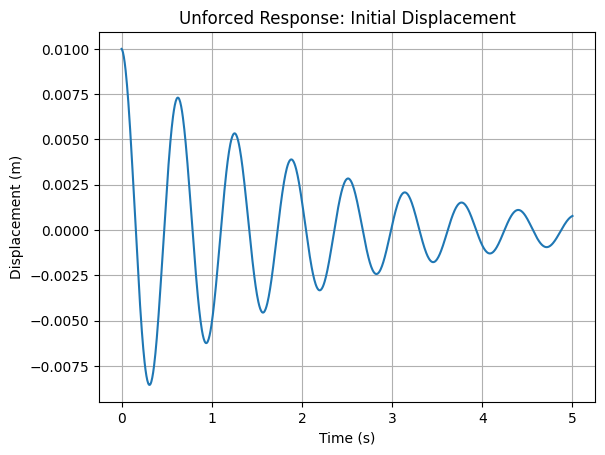

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 5, 1000)
# Parameters for Mode 1
zeta = 0.05; wn = 10; wd = wn * np.sqrt(1-zeta**2)
x = np.exp(-zeta*wn*t) * (0.01 * np.cos(wd*t))

plt.plot(t, x)
plt.title('Unforced Response: Initial Displacement')
plt.xlabel('Time (s)'); plt.ylabel('Displacement (m)')
plt.grid(True)

Text(0.5, 1.0, 'Forced Response at Different Speeds')

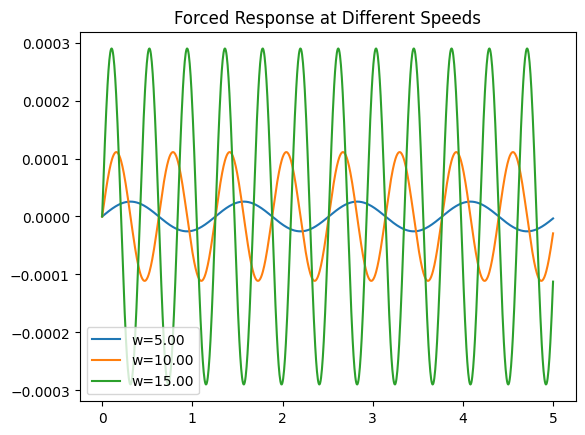

In [8]:
w_speeds = [wn*0.5, wn, wn*1.5] # Three choices
#Define missing parameters
m0 = 0.1       # Unbalanced motor mass (kg)
e = 0.02       # Eccentricity (m)
k = 2000.0     # Spring stiffness (N/m)
m = 2.0        # Effective mass of beam (kg)
c = 2 * zeta * np.sqrt(k*m)
for w in w_speeds:
    force_resp = (m0*e*w**2 / np.sqrt((k - m*w**2)**2 + (c*w)**2)) * np.sin(w*t)
    plt.plot(t, force_resp, label=f'w={w:.2f}')
plt.legend()
plt.title('Forced Response at Different Speeds')

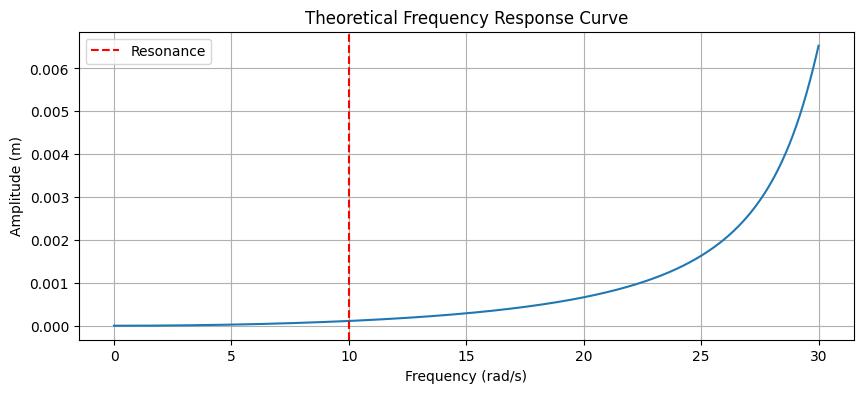

In [10]:
w_range = np.linspace(0, wn*3, 1000)

# Frequency Response Function (FRF) magnitude
mag = (m0 * e * w_range**2) / np.sqrt((k - m * w_range**2)**2 + (c * w_range)**2)
plt.figure(figsize=(10, 4))
plt.plot(w_range, mag)
plt.axvline(wn, color='r', linestyle='--', label='Resonance')
plt.title('Theoretical Frequency Response Curve')
plt.xlabel('Frequency (rad/s)'); plt.ylabel('Amplitude (m)'); plt.legend(); plt.grid(True)
plt.show()